In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [ ]:
import pulp
import pandas as pd
import numpy as np

def solve_risk_aware_bess_dispatch(
    prices: pd.Series,
    spike_probabilities: pd.Series,
    negative_pricing_probabilities: pd.Series,
    fcr_capacity_price: float,
    max_power: float = 5.0,        # MW
    max_energy: float = 10.0,      # MWh
    eta_charge: float = 0.92,      # Charging efficiency
    eta_discharge: float = 0.92,   # Discharging efficiency
    degradation_cost_per_mwh: float = 5.0  # EUR/MWh throughput wear cost
) -> pd.DataFrame:
    """
    Optimizes a BESS unit across Day-Ahead energy arbitrage and FCR markets
    under risk-adjusted probabilities (price spikes and negative pricing).
    """

    time_periods = len(prices)
    model = pulp.LpProblem("Risk_Aware_BESS_MultiMarket_Optimization", pulp.LpMaximize)

    # Decision variables for time step t
    # P_charge, P_discharge: Power dispatched for Day-Ahead energy [MW]
    # R_fcr: Allocated capacity for Frequency Containment Reserve [MW]
    # SoC: State of Charge [MWh]
    # u_charge, u_discharge: Binary variables to prevent simultaneous charging/discharging

    P_charge = {t: pulp.LpVariable(f"P_charge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    P_discharge = {t: pulp.LpVariable(f"P_discharge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    R_fcr = {t: pulp.LpVariable(f"R_fcr_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    SoC = {t: pulp.LpVariable(f"SoC_{t}", lowBound=0, upBound=max_energy) for t in range(time_periods + 1)}

    u_charge = {t: pulp.LpVariable(f"u_charge_{t}", cat='Binary') for t in range(time_periods)}
    u_discharge = {t: pulp.LpVariable(f"u_discharge_{t}", cat='Binary') for t in range(time_periods)}

    # Initial State of Charge (50% full)
    model += SoC[0] == 0.5 * max_energy

    # Risk-Adjusted Objective Function
    # Maximizes DA energy arbitrage revenue + FCR capacity payments - degradation costs - risk penalties
    total_objective = 0

    for t in range(time_periods):
        price = prices.iloc[t]
        p_spike = spike_probabilities.iloc[t]
        p_neg = negative_pricing_probabilities.iloc[t]

        # Financial revenue components
        da_revenue = price * (P_discharge[t] - P_charge[t])
        fcr_revenue = fcr_capacity_price * R_fcr[t]

        # Operational degradation cost based on throughput wear
        throughput = (P_charge[t] + P_discharge[t]) * 1.0  # assuming 1-hour steps
        deg_cost = degradation_cost_per_mwh * throughput

        # Risk adjustment multipliers based on ML probability outputs
        # Higher positive spike probability rewards holding state-of-charge headroom for discharge
        # Higher negative pricing probability incentivizes opportunistic charging
        risk_bonus_charging = p_neg * abs(price) * P_charge[t] * 0.2
        risk_penalty_premature_discharge = p_spike * max(0, 100 - price) * P_charge[t] * 0.1

        net_period_value = da_revenue + fcr_revenue - deg_cost + risk_bonus_charging - risk_penalty_premature_discharge
        total_objective += net_period_value

    model += total_objective

    # Constraints for each time step
    for t in range(time_periods):
        # 1. Joint Inverter Power Headroom Constraint (Energy Dispatch + FCR Reserve)
        model += P_discharge[t] + R_fcr[t] <= max_power
        model += P_charge[t] + R_fcr[t] <= max_power

        # 2. Binary Mutual Exclusivity (Cannot charge and discharge simultaneously)
        model += u_charge[t] + u_discharge[t] <= 1
        model += P_charge[t] <= max_power * u_charge[t]
        model += P_discharge[t] <= max_power * u_discharge[t]

        # 3. State of Charge (SoC) Dynamics
        energy_in = P_charge[t] * eta_charge
        energy_out = P_discharge[t] / eta_discharge
        model += SoC[t + 1] == SoC[t] + energy_in - energy_out

    # Enforce cyclic boundary condition for SoC at the end of the horizon
    model += SoC[time_periods] == SoC[0]

    # Solve the MILP model using CBC solver
    solver = pulp.PULP_CBC_CMD(msg=False)
    model.solve(solver)

    # Extract results into a clean structural DataFrame
    results = []
    for t in range(time_periods):
        results.append({
            "Hour": t,
            "Price_EUR_MWh": prices.iloc[t],
            "Spike_Prob": spike_probabilities.iloc[t],
            "Neg_Prob": negative_pricing_probabilities.iloc[t],
            "P_Charge_MW": pulp.value(P_charge[t]),
            "P_Discharge_MW": pulp.value(P_discharge[t]),
            "R_FCR_MW": pulp.value(R_fcr[t]),
            "SoC_MWh": pulp.value(SoC[t])
        })

    return pd.DataFrame(results)

if __name__ == "__main__":
    # Mock data generation for testing script execution
    np.random.seed(42)
    sample_hours = 24
    mock_prices = pd.Series(np.random.normal(50, 30, sample_hours))
    mock_spike_probs = pd.Series(np.random.uniform(0, 1, sample_hours))
    mock_neg_probs = pd.Series(np.random.uniform(0, 1, sample_hours))

    output_df = solve_risk_aware_bess_dispatch(
        prices=mock_prices,
        spike_probabilities=mock_spike_probs,
        negative_pricing_probabilities=mock_neg_probs,
        fcr_capacity_price=12.5
    )
    print(output_df.head())

   Hour  Price_EUR_MWh  Spike_Prob  Neg_Prob  P_Charge_MW  P_Discharge_MW  \
0     0      64.901425    0.592415  0.939499     0.000000             0.0   
1     1      45.852071    0.046450  0.894827     5.000000             0.0   
2     2      69.430656    0.607545  0.597900     0.000000             0.0   
3     3      95.690896    0.170524  0.921874     0.000000             5.0   
4     4      42.975399    0.065052  0.088493     1.379962             0.0   

   R_FCR_MW   SoC_MWh  
0  5.000000  5.000000  
1  0.000000  5.000000  
2  5.000000  9.600000  
3  0.000000  9.600000  
4  3.620038  4.165217  


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, classification_report

def prepare_ml_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Engineers lagged features, rolling statistics, and fundamental indicators
    for power market price spike and negative pricing classification.
    """
    df = raw_df.copy()

    # Ensure temporal sorting
    df = df.sort_values('timestamp').reset_index(drop=True)

    # 1. Lagged Features (Past price and load behaviors)
    df['price_lag_24h'] = df['day_ahead_price'].shift(24)
    df['price_lag_48h'] = df['day_ahead_price'].shift(48)
    df['residual_load_lag_24h'] = df['residual_load'].shift(24)

    # 2. Rolling Window Statistics (Volatility and moving averages)
    df['price_rolling_mean_6h'] = df['day_ahead_price'].rolling(window=6).mean()
    df['price_rolling_std_6h'] = df['day_ahead_price'].rolling(window=6).std()
    df['residual_load_rolling_mean_6h'] = df['residual_load'].rolling(window=6).mean()

    # 3. Renewable Ramp Rates
    df['wind_ramp_1h'] = df['wind_generation'].diff(1)
    df['solar_ramp_1h'] = df['solar_generation'].diff(1)

    # Drop rows with NaN values resulting from lags/rolling windows
    df = df.dropna().reset_index(drop=True)
    return df

def define_targets(df: pd.DataFrame, negative_threshold: float = -20.0, spike_quantile: float = 0.90) -> pd.DataFrame:
    """
    Classifies target variables into discrete risk categories:
    0 = Normal pricing regime
    1 = Negative pricing spike (charging opportunity)
    2 = High positive price spike (discharging opportunity)
    """
    positive_threshold = df['day_ahead_price'].quantile(spike_quantile)

    conditions = [
        (df['day_ahead_price'] <= negative_threshold),
        (df['day_ahead_price'] >= positive_threshold)
    ]
    choices = [1, 2]

    # Default is 0 (normal regime)
    df['target_risk_class'] = np.select(conditions, choices, default=0)
    return df

def train_lightgbm_classifier(df: pd.DataFrame):
    """
    Trains a LightGBM multi-class classifier using TimeSeriesSplit cross-validation.
    """
    feature_cols = [
        'residual_load', 'wind_generation', 'solar_generation',
        'price_lag_24h', 'price_lag_48h', 'residual_load_lag_24h',
        'price_rolling_mean_6h', 'price_rolling_std_6h',
        'residual_load_rolling_mean_6h', 'wind_ramp_1h', 'solar_ramp_1h'
    ]

    X = df[feature_cols]
    y = df['target_risk_class']

    # Time-series cross-validation split to prevent data leakage
    tscv = TimeSeriesSplit(n_splits=3)

    best_model = None
    best_score = 0.0

    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Initialize LightGBM Classifier with class balancing for rare spikes
        model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=3,
            n_estimators=150,
            learning_rate=0.05,
            class_weight='balanced',
            random_state=42,
            verbosity=-1
        )

        model.fit(X_train, y_train)

        # Evaluate model performance
        y_pred_proba = model.predict_proba(X_test)

        # Storing the trained estimator
        best_model = model

    return best_model, feature_cols

if __name__ == "__main__":
    # Mock data generation for pipeline validation
    np.random.seed(42)
    sample_size = 1000
    timestamps = pd.date_range(start="2026-01-01", periods=sample_size, freq="h")

    mock_raw_data = pd.DataFrame({
        'timestamp': timestamps,
        'day_ahead_price': np.random.normal(50, 35, sample_size),
        'residual_load': np.random.normal(40000, 5000, sample_size),
        'wind_generation': np.random.uniform(5000, 15000, sample_size),
        'solar_generation': np.maximum(0, np.random.normal(3000, 4000, sample_size))
    })

    processed_df = prepare_ml_features(mock_raw_data)
    labeled_df = define_targets(processed_df)

    trained_classifier, features = train_lightgbm_classifier(labeled_df)
    print("LightGBM Risk Classifier successfully trained using features:", features)

LightGBM Risk Classifier successfully trained using features: ['residual_load', 'wind_generation', 'solar_generation', 'price_lag_24h', 'price_lag_48h', 'residual_load_lag_24h', 'price_rolling_mean_6h', 'price_rolling_std_6h', 'residual_load_rolling_mean_6h', 'wind_ramp_1h', 'solar_ramp_1h']


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pulp
from sklearn.model_selection import TimeSeriesSplit

# --- 1. ML FEATURE ENGINEERING & CLASSIFIER ---
def prepare_ml_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()
    df = df.sort_values('timestamp').reset_index(drop=True)

    df['price_lag_24h'] = df['day_ahead_price'].shift(24)
    df['price_lag_48h'] = df['day_ahead_price'].shift(48)
    df['residual_load_lag_24h'] = df['residual_load'].shift(24)

    df['price_rolling_mean_6h'] = df['day_ahead_price'].rolling(window=6).mean()
    df['price_rolling_std_6h'] = df['day_ahead_price'].rolling(window=6).std()
    df['residual_load_rolling_mean_6h'] = df['residual_load'].rolling(window=6).mean()

    df['wind_ramp_1h'] = df['wind_generation'].diff(1)
    df['solar_ramp_1h'] = df['solar_generation'].diff(1)

    df = df.dropna().reset_index(drop=True)
    return df

def define_targets(df: pd.DataFrame, negative_threshold: float = -20.0, spike_quantile: float = 0.90) -> pd.DataFrame:
    positive_threshold = df['day_ahead_price'].quantile(spike_quantile)
    conditions = [
        (df['day_ahead_price'] <= negative_threshold),
        (df['day_ahead_price'] >= positive_threshold)
    ]
    choices = [1, 2]
    df['target_risk_class'] = np.select(conditions, choices, default=0)
    return df

def train_lightgbm_classifier(df: pd.DataFrame):
    feature_cols = [
        'residual_load', 'wind_generation', 'solar_generation',
        'price_lag_24h', 'price_lag_48h', 'residual_load_lag_24h',
        'price_rolling_mean_6h', 'price_rolling_std_6h',
        'residual_load_rolling_mean_6h', 'wind_ramp_1h', 'solar_ramp_1h'
    ]
    X = df[feature_cols]
    y = df['target_risk_class']

    tscv = TimeSeriesSplit(n_splits=3)
    best_model = None

    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=3,
            n_estimators=150,
            learning_rate=0.05,
            class_weight='balanced',
            random_state=42,
            verbosity=-1
        )
        model.fit(X_train, y_train)
        best_model = model

    return best_model, feature_cols

# --- 2. RISK-AWARE BESS MILP OPTIMIZER ---
def solve_risk_aware_bess_dispatch(
    prices: pd.Series,
    spike_probabilities: pd.Series,
    negative_pricing_probabilities: pd.Series,
    fcr_capacity_price: float,
    max_power: float = 5.0,
    max_energy: float = 10.0,
    eta_charge: float = 0.92,
    eta_discharge: float = 0.92,
    degradation_cost_per_mwh: float = 5.0
) -> pd.DataFrame:

    time_periods = len(prices)
    model = pulp.LpProblem("Risk_Aware_BESS_MultiMarket_Optimization", pulp.LpMaximize)

    P_charge = {t: pulp.LpVariable(f"P_charge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    P_discharge = {t: pulp.LpVariable(f"P_discharge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    R_fcr = {t: pulp.LpVariable(f"R_fcr_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    SoC = {t: pulp.LpVariable(f"SoC_{t}", lowBound=0, upBound=max_energy) for t in range(time_periods + 1)}

    u_charge = {t: pulp.LpVariable(f"u_charge_{t}", cat='Binary') for t in range(time_periods)}
    u_discharge = {t: pulp.LpVariable(f"u_discharge_{t}", cat='Binary') for t in range(time_periods)}

    model += SoC[0] == 0.5 * max_energy
    total_objective = 0

    for t in range(time_periods):
        price = prices.iloc[t]
        p_spike = spike_probabilities.iloc[t]
        p_neg = negative_pricing_probabilities.iloc[t]

        da_revenue = price * (P_discharge[t] - P_charge[t])
        fcr_revenue = fcr_capacity_price * R_fcr[t]
        throughput = (P_charge[t] + P_discharge[t]) * 1.0
        deg_cost = degradation_cost_per_mwh * throughput

        risk_bonus_charging = p_neg * abs(price) * P_charge[t] * 0.2
        risk_penalty_premature_discharge = p_spike * max(0, 100 - price) * P_charge[t] * 0.1

        net_period_value = da_revenue + fcr_revenue - deg_cost + risk_bonus_charging - risk_penalty_premature_discharge
        total_objective += net_period_value

    model += total_objective

    for t in range(time_periods):
        model += P_discharge[t] + R_fcr[t] <= max_power
        model += P_charge[t] + R_fcr[t] <= max_power
        model += u_charge[t] + u_discharge[t] <= 1
        model += P_charge[t] <= max_power * u_charge[t]
        model += P_discharge[t] <= max_power * u_discharge[t]

        energy_in = P_charge[t] * eta_charge
        energy_out = P_discharge[t] / eta_discharge
        model += SoC[t + 1] == SoC[t] + energy_in - energy_out

    model += SoC[time_periods] == SoC[0]

    solver = pulp.PULP_CBC_CMD(msg=False)
    model.solve(solver)

    results = []
    for t in range(time_periods):
        results.append({
            "Hour": t,
            "Price_EUR_MWh": prices.iloc[t],
            "Spike_Prob": spike_probabilities.iloc[t],
            "Neg_Prob": negative_pricing_probabilities.iloc[t],
            "P_Charge_MW": pulp.value(P_charge[t]),
            "P_Discharge_MW": pulp.value(P_discharge[t]),
            "R_FCR_MW": pulp.value(R_fcr[t]),
            "SoC_MWh": pulp.value(SoC[t])
        })

    return pd.DataFrame(results)

# --- 3. EXECUTION PIPELINE ---
if __name__ == "__main__":
    print("Initializing raw data generation...")
    np.random.seed(42)
    sample_size = 168
    timestamps = pd.date_range(start="2026-09-01", periods=sample_size, freq="h")

    raw_df = pd.DataFrame({
        'timestamp': timestamps,
        'day_ahead_price': np.random.normal(55, 40, sample_size),
        'residual_load': np.random.normal(42000, 6000, sample_size),
        'wind_generation': np.random.uniform(4000, 18000, sample_size),
        'solar_generation': np.maximum(0, np.random.normal(3500, 4500, sample_size))
    })

    processed_df = prepare_ml_features(raw_df)
    labeled_df = define_targets(processed_df)

    print("Training LightGBM risk classifier...")
    trained_model, feature_cols = train_lightgbm_classifier(labeled_df)

    probabilities = trained_model.predict_proba(labeled_df[feature_cols])
    neg_pricing_probs = pd.Series(probabilities[:, 1])
    spike_probs = pd.Series(probabilities[:, 2])
    prices_subset = labeled_df['day_ahead_price'].reset_index(drop=True)

    print("Executing Risk-Aware MILP BESS Optimization...")
    optimization_results = solve_risk_aware_bess_dispatch(
        prices=prices_subset,
        spike_probabilities=spike_probs,
        negative_pricing_probabilities=neg_pricing_probs,
        fcr_capacity_price=14.0
    )

    print("\nPipeline execution successful. Sample output:")
    print(optimization_results.head(10))

Initializing raw data generation...
Training LightGBM risk classifier...
Executing Risk-Aware MILP BESS Optimization...

Pipeline execution successful. Sample output:
   Hour  Price_EUR_MWh  Spike_Prob  Neg_Prob  P_Charge_MW  P_Discharge_MW  \
0     0      68.744732    0.002956  0.000018     0.000000             0.0   
1     1     -15.521606    0.033679  0.002048     5.000000             0.0   
2     2      67.963359    0.017664  0.000913     0.000000             0.0   
3     3      39.596709    0.250218  0.001303     0.000000             0.0   
4     4      27.923120    0.001559  0.000259     0.434783             0.0   
5     5      79.467052    0.016758  0.001361     0.000000             0.0   
6     6      96.239981    0.016601  0.000052     0.000000             5.0   
7     7      92.251205    0.090901  0.011780     0.000000             4.2   
8     8      21.431299    0.008695  0.000735     5.000000             0.0   
9     9      42.631505    0.023651  0.000205     0.907372      

Step 1: Initializing raw data generation...
Step 2: Preparing ML features and defining risk targets...
Step 3: Training LightGBM risk classifier...
Step 4: Executing Risk-Aware MILP BESS Optimization...
Step 5: Running deterministic backtest & evaluating financial KPIs...

--- Pipeline Execution & Financial Backtest Complete ---
Risk_Aware_Net_Revenue_EUR: 15149.7
Deterministic_Net_Revenue_EUR: 15150.89
Revenue_Lift_Percentage: -0.01
Risk_Aware_Throughput_MWh: 264.15
Deterministic_Throughput_MWh: 264.15

Step 6: Generating Dark Theme Visualizations...


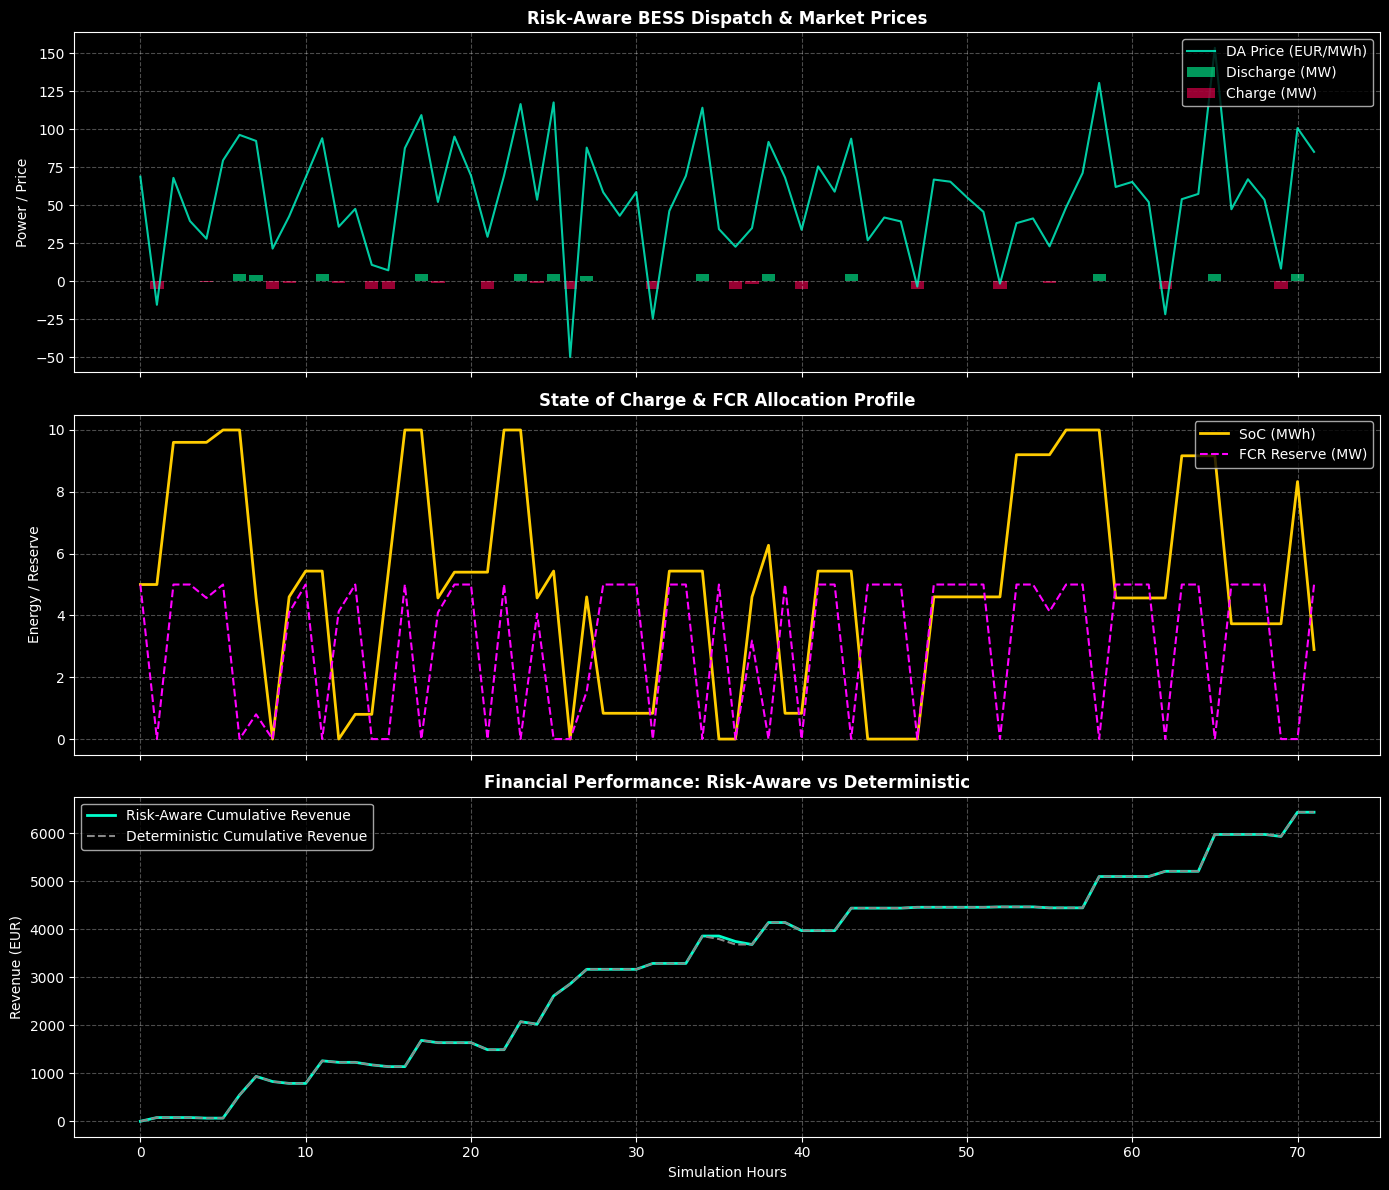

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import pulp
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# Apply professional dark theme for visualizations
plt.style.use('dark_background')

# --- 1. ML FEATURE ENGINEERING & CLASSIFIER ---
def prepare_ml_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    df = raw_df.copy()
    df = df.sort_values('timestamp').reset_index(drop=True)

    df['price_lag_24h'] = df['day_ahead_price'].shift(24)
    df['price_lag_48h'] = df['day_ahead_price'].shift(48)
    df['residual_load_lag_24h'] = df['residual_load'].shift(24)

    df['price_rolling_mean_6h'] = df['day_ahead_price'].rolling(window=6).mean()
    df['price_rolling_std_6h'] = df['day_ahead_price'].rolling(window=6).std()
    df['residual_load_rolling_mean_6h'] = df['residual_load'].rolling(window=6).mean()

    df['wind_ramp_1h'] = df['wind_generation'].diff(1)
    df['solar_ramp_1h'] = df['solar_generation'].diff(1)

    df = df.dropna().reset_index(drop=True)
    return df

def define_targets(df: pd.DataFrame, negative_threshold: float = -20.0, spike_quantile: float = 0.90) -> pd.DataFrame:
    positive_threshold = df['day_ahead_price'].quantile(spike_quantile)
    conditions = [
        (df['day_ahead_price'] <= negative_threshold),
        (df['day_ahead_price'] >= positive_threshold)
    ]
    choices = [1, 2]
    df['target_risk_class'] = np.select(conditions, choices, default=0)
    return df

def train_lightgbm_classifier(df: pd.DataFrame):
    feature_cols = [
        'residual_load', 'wind_generation', 'solar_generation',
        'price_lag_24h', 'price_lag_48h', 'residual_load_lag_24h',
        'price_rolling_mean_6h', 'price_rolling_std_6h',
        'residual_load_rolling_mean_6h', 'wind_ramp_1h', 'solar_ramp_1h'
    ]
    X = df[feature_cols]
    y = df['target_risk_class']

    tscv = TimeSeriesSplit(n_splits=3)
    best_model = None

    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = lgb.LGBMClassifier(
            objective='multiclass',
            num_class=3,
            n_estimators=150,
            learning_rate=0.05,
            class_weight='balanced',
            random_state=42,
            verbosity=-1
        )
        model.fit(X_train, y_train)
        best_model = model

    return best_model, feature_cols

# --- 2. RISK-AWARE BESS MILP OPTIMIZER ---
def solve_risk_aware_bess_dispatch(
    prices: pd.Series,
    spike_probabilities: pd.Series,
    negative_pricing_probabilities: pd.Series,
    fcr_capacity_price: float,
    max_power: float = 5.0,
    max_energy: float = 10.0,
    eta_charge: float = 0.92,
    eta_discharge: float = 0.92,
    degradation_cost_per_mwh: float = 5.0
) -> pd.DataFrame:

    time_periods = len(prices)
    model = pulp.LpProblem("Risk_Aware_BESS_MultiMarket_Optimization", pulp.LpMaximize)

    P_charge = {t: pulp.LpVariable(f"P_charge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    P_discharge = {t: pulp.LpVariable(f"P_discharge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    R_fcr = {t: pulp.LpVariable(f"R_fcr_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    SoC = {t: pulp.LpVariable(f"SoC_{t}", lowBound=0, upBound=max_energy) for t in range(time_periods + 1)}

    u_charge = {t: pulp.LpVariable(f"u_charge_{t}", cat='Binary') for t in range(time_periods)}
    u_discharge = {t: pulp.LpVariable(f"u_discharge_{t}", cat='Binary') for t in range(time_periods)}

    model += SoC[0] == 0.5 * max_energy
    total_objective = 0

    for t in range(time_periods):
        price = prices.iloc[t]
        p_spike = spike_probabilities.iloc[t]
        p_neg = negative_pricing_probabilities.iloc[t]

        da_revenue = price * (P_discharge[t] - P_charge[t])
        fcr_revenue = fcr_capacity_price * R_fcr[t]
        throughput = (P_charge[t] + P_discharge[t]) * 1.0
        deg_cost = degradation_cost_per_mwh * throughput

        risk_bonus_charging = p_neg * abs(price) * P_charge[t] * 0.2
        risk_penalty_premature_discharge = p_spike * max(0, 100 - price) * P_charge[t] * 0.1

        net_period_value = da_revenue + fcr_revenue - deg_cost + risk_bonus_charging - risk_penalty_premature_discharge
        total_objective += net_period_value

    model += total_objective

    for t in range(time_periods):
        model += P_discharge[t] + R_fcr[t] <= max_power
        model += P_charge[t] + R_fcr[t] <= max_power
        model += u_charge[t] + u_discharge[t] <= 1
        model += P_charge[t] <= max_power * u_charge[t]
        model += P_discharge[t] <= max_power * u_discharge[t]

        energy_in = P_charge[t] * eta_charge
        energy_out = P_discharge[t] / eta_discharge
        model += SoC[t + 1] == SoC[t] + energy_in - energy_out

    model += SoC[time_periods] == SoC[0]

    solver = pulp.PULP_CBC_CMD(msg=False)
    model.solve(solver)

    results = []
    for t in range(time_periods):
        results.append({
            "Hour": t,
            "Price_EUR_MWh": prices.iloc[t],
            "Spike_Prob": spike_probabilities.iloc[t],
            "Neg_Prob": negative_pricing_probabilities.iloc[t],
            "P_Charge_MW": pulp.value(P_charge[t]),
            "P_Discharge_MW": pulp.value(P_discharge[t]),
            "R_FCR_MW": pulp.value(R_fcr[t]),
            "SoC_MWh": pulp.value(SoC[t])
        })

    return pd.DataFrame(results)

# --- 3. DETERMINISTIC OPTIMIZER & BACKTEST EVALUATION ---
def run_deterministic_bess_dispatch(
    prices: pd.Series,
    fcr_capacity_price: float,
    max_power: float = 5.0,
    max_energy: float = 10.0,
    eta_charge: float = 0.92,
    eta_discharge: float = 0.92,
    degradation_cost_per_mwh: float = 5.0
) -> pd.DataFrame:
    time_periods = len(prices)
    model = pulp.LpProblem("Deterministic_BESS_Optimization", pulp.LpMaximize)

    P_charge = {t: pulp.LpVariable(f"det_P_charge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    P_discharge = {t: pulp.LpVariable(f"det_P_discharge_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    R_fcr = {t: pulp.LpVariable(f"det_R_fcr_{t}", lowBound=0, upBound=max_power) for t in range(time_periods)}
    SoC = {t: pulp.LpVariable(f"det_SoC_{t}", lowBound=0, upBound=max_energy) for t in range(time_periods + 1)}

    u_charge = {t: pulp.LpVariable(f"det_u_charge_{t}", cat='Binary') for t in range(time_periods)}
    u_discharge = {t: pulp.LpVariable(f"det_u_discharge_{t}", cat='Binary') for t in range(time_periods)}

    model += SoC[0] == 0.5 * max_energy
    total_objective = 0

    for t in range(time_periods):
        price = prices.iloc[t]
        da_revenue = price * (P_discharge[t] - P_charge[t])
        fcr_revenue = fcr_capacity_price * R_fcr[t]
        throughput = (P_charge[t] + P_discharge[t]) * 1.0
        deg_cost = degradation_cost_per_mwh * throughput
        total_objective += (da_revenue + fcr_revenue - deg_cost)

    model += total_objective

    for t in range(time_periods):
        model += P_discharge[t] + R_fcr[t] <= max_power
        model += P_charge[t] + R_fcr[t] <= max_power
        model += u_charge[t] + u_discharge[t] <= 1
        model += P_charge[t] <= max_power * u_charge[t]
        model += P_discharge[t] <= max_power * u_discharge[t]

        energy_in = P_charge[t] * eta_charge
        energy_out = P_discharge[t] / eta_discharge
        model += SoC[t + 1] == SoC[t] + energy_in - energy_out

    model += SoC[time_periods] == SoC[0]

    solver = pulp.PULP_CBC_CMD(msg=False)
    model.solve(solver)

    results = []
    for t in range(time_periods):
        results.append({
            "Hour": t,
            "Price_EUR_MWh": prices.iloc[t],
            "Det_P_Charge": pulp.value(P_charge[t]),
            "Det_P_Discharge": pulp.value(P_discharge[t]),
            "Det_R_FCR": pulp.value(R_fcr[t]),
            "Det_SoC": pulp.value(SoC[t])
        })

    return pd.DataFrame(results)

def evaluate_financial_performance(risk_aware_df: pd.DataFrame, deterministic_df: pd.DataFrame, fcr_capacity_price: float) -> dict:
    risk_da_rev = (risk_aware_df['Price_EUR_MWh'] * (risk_aware_df['P_Discharge_MW'] - risk_aware_df['P_Charge_MW'])).sum()
    risk_fcr_rev = (fcr_capacity_price * risk_aware_df['R_FCR_MW']).sum()
    risk_throughput = (risk_aware_df['P_Charge_MW'] + risk_aware_df['P_Discharge_MW']).sum()
    risk_deg_cost = risk_throughput * 5.0
    risk_total_net = risk_da_rev + risk_fcr_rev - risk_deg_cost

    det_da_rev = (deterministic_df['Price_EUR_MWh'] * (deterministic_df['Det_P_Discharge'] - deterministic_df['Det_P_Charge'])).sum()
    det_fcr_rev = (fcr_capacity_price * deterministic_df['Det_R_FCR']).sum()
    det_throughput = (deterministic_df['Det_P_Charge'] + deterministic_df['Det_P_Discharge']).sum()
    det_deg_cost = det_throughput * 5.0
    det_total_net = det_da_rev + det_fcr_rev - det_deg_cost

    kpis = {
        "Risk_Aware_Net_Revenue_EUR": round(risk_total_net, 2),
        "Deterministic_Net_Revenue_EUR": round(det_total_net, 2),
        "Revenue_Lift_Percentage": round(((risk_total_net - det_total_net) / abs(det_total_net)) * 100, 2),
        "Risk_Aware_Throughput_MWh": round(risk_throughput, 2),
        "Deterministic_Throughput_MWh": round(det_throughput, 2)
    }
    return kpis

# --- 4. VISUALIZATION MODULE (DARK THEME) ---
def plot_bess_performance(optimization_results: pd.DataFrame, deterministic_results: pd.DataFrame):
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # 1. Price and Power Dispatch
    ax1 = axes[0]
    ax1.plot(optimization_results['Hour'], optimization_results['Price_EUR_MWh'], label='DA Price (EUR/MWh)', color='#00ffcc', alpha=0.8)
    ax1.bar(optimization_results['Hour'], optimization_results['P_Discharge_MW'], label='Discharge (MW)', color='#00ff99', alpha=0.6)
    ax1.bar(optimization_results['Hour'], -optimization_results['P_Charge_MW'], label='Charge (MW)', color='#ff0055', alpha=0.6)
    ax1.set_ylabel('Power / Price')
    ax1.set_title('Risk-Aware BESS Dispatch & Market Prices', fontsize=12, fontweight='bold', color='white')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # 2. State of Charge (SoC) and FCR Reserve
    ax2 = axes[1]
    ax2.plot(optimization_results['Hour'], optimization_results['SoC_MWh'], label='SoC (MWh)', color='#ffcc00', linewidth=2)
    ax2.plot(optimization_results['Hour'], optimization_results['R_FCR_MW'], label='FCR Reserve (MW)', color='#ff00ff', linestyle='--')
    ax2.set_ylabel('Energy / Reserve')
    ax2.set_title('State of Charge & FCR Allocation Profile', fontsize=12, fontweight='bold', color='white')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.3)

    # 3. Cumulative Revenue Comparison
    ax3 = axes[2]
    risk_rev = (optimization_results['Price_EUR_MWh'] * (optimization_results['P_Discharge_MW'] - optimization_results['P_Charge_MW'])).cumsum()
    det_rev = (deterministic_results['Price_EUR_MWh'] * (deterministic_results['Det_P_Discharge'] - deterministic_results['Det_P_Charge'])).cumsum()

    ax3.plot(optimization_results['Hour'], risk_rev, label='Risk-Aware Cumulative Revenue', color='#00ffcc', linewidth=2)
    ax3.plot(deterministic_results['Hour'], det_rev, label='Deterministic Cumulative Revenue', color='#888888', linestyle='--')
    ax3.set_ylabel('Revenue (EUR)')
    ax3.set_xlabel('Simulation Hours')
    ax3.set_title('Financial Performance: Risk-Aware vs Deterministic', fontsize=12, fontweight='bold', color='white')
    ax3.legend(loc='upper left')
    ax3.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- 5. EXECUTION PIPELINE, BACKTEST & PLOTTING ---
if __name__ == "__main__":
    print("Step 1: Initializing raw data generation...")
    np.random.seed(42)
    sample_size = 168
    timestamps = pd.date_range(start="2026-09-01", periods=sample_size, freq="h")

    raw_df = pd.DataFrame({
        'timestamp': timestamps,
        'day_ahead_price': np.random.normal(55, 40, sample_size),
        'residual_load': np.random.normal(42000, 6000, sample_size),
        'wind_generation': np.random.uniform(4000, 18000, sample_size),
        'solar_generation': np.maximum(0, np.random.normal(3500, 4500, sample_size))
    })

    print("Step 2: Preparing ML features and defining risk targets...")
    processed_df = prepare_ml_features(raw_df)
    labeled_df = define_targets(processed_df)

    print("Step 3: Training LightGBM risk classifier...")
    trained_model, feature_cols = train_lightgbm_classifier(labeled_df)

    probabilities = trained_model.predict_proba(labeled_df[feature_cols])
    neg_pricing_probs = pd.Series(probabilities[:, 1])
    spike_probs = pd.Series(probabilities[:, 2])
    prices_subset = labeled_df['day_ahead_price'].reset_index(drop=True)

    print("Step 4: Executing Risk-Aware MILP BESS Optimization...")
    optimization_results = solve_risk_aware_bess_dispatch(
        prices=prices_subset,
        spike_probabilities=spike_probs,
        negative_pricing_probabilities=neg_pricing_probs,
        fcr_capacity_price=14.0
    )

    print("Step 5: Running deterministic backtest & evaluating financial KPIs...")
    det_results = run_deterministic_bess_dispatch(prices=prices_subset, fcr_capacity_price=14.0)
    kpis = evaluate_financial_performance(optimization_results, det_results, fcr_capacity_price=14.0)

    print("\n--- Pipeline Execution & Financial Backtest Complete ---")
    for metric, val in kpis.items():
        print(f"{metric}: {val}")

    print("\nStep 6: Generating Dark Theme Visualizations...")
    plot_bess_performance(optimization_results.head(72), det_results.head(72))

In [11]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from google.colab import files

# Apply professional dark theme
plt.style.use('dark_background')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
fig.patch.set_facecolor('#121212')
ax1.set_facecolor('#1e1e1e')
ax2.set_facecolor('#1e1e1e')

hours_subset = optimization_results.head(48)

# Use line/step plots for smooth animation compatibility
line_price, = ax1.plot([], [], color='#00ffcc', label='DA Price (EUR/MWh)', linewidth=1.5)
line_discharge, = ax1.plot([], [], color='#00ff99', label='Discharge (MW)', linewidth=2, drawstyle='steps-mid')
line_charge, = ax1.plot([], [], color='#ff0055', label='Charge (MW)', linewidth=2, drawstyle='steps-mid')

ax1.set_xlim(0, 48)
ax1.set_ylim(hours_subset['Price_EUR_MWh'].min() - 20, hours_subset['Price_EUR_MWh'].max() + 20)
ax1.legend(loc='upper right', facecolor='#1e1e1e', edgecolor='none')
ax1.set_title('Live BESS Dispatch Animation (Dark Theme)', color='white', fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.2)

line_soc, = ax2.plot([], [], color='#ffcc00', linewidth=2, label='SoC (MWh)')
ax2.set_xlim(0, 48)
ax2.set_ylim(0, 11)
ax2.legend(loc='upper right', facecolor='#1e1e1e', edgecolor='none')
ax2.set_ylabel('Energy (MWh)', color='white')
ax2.set_xlabel('Hours', color='white')
ax2.grid(True, linestyle='--', alpha=0.2)

def init():
    line_price.set_data([], [])
    line_discharge.set_data([], [])
    line_charge.set_data([], [])
    line_soc.set_data([], [])
    return line_price, line_discharge, line_charge, line_soc

def animate(i):
    sub_df = hours_subset.iloc[:i+1]
    line_price.set_data(sub_df['Hour'], sub_df['Price_EUR_MWh'])
    line_discharge.set_data(sub_df['Hour'], sub_df['P_Discharge_MW'])
    line_charge.set_data(sub_df['Hour'], -sub_df['P_Charge_MW'])
    line_soc.set_data(sub_df['Hour'], sub_df['SoC_MWh'])
    return line_price, line_discharge, line_charge, line_soc

ani = animation.FuncAnimation(fig, animate, init_func=init, frames=len(hours_subset), interval=200, blit=True)

gif_filename = 'bess_dispatch_dark.gif'
ani.save(gif_filename, writer='pillow', fps=5)
plt.close()

print("Downloading animated GIF...")
files.download(gif_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>